**VERSION v4**: I changed some stuff in the code (explained below) and used the new signal catalog, and results came out very weird. In order to understand, I performed the changes to the code using the old signal catalog and found that now it gives the same results (could have been a bug or an actual problem with the catalog). 

#### a little explanation

Starting with old code + old lists, I'm updating each thing one at a time to check if results remain the same as with *v3* (which gave the same results as the Brandon code if one reverted to constellation-wide fitting). I'm going through this order to alterations:
1. New PSD functions (updated `psd_models.py`) and corrected a single signal modulation (it was incorrectly using the "Rate" column instead of defining the signal directly from the modulation).
   - Result: Slightly higher peaks in one or other fitting which results in slightly better fits; some alphas also are quite different, but those correspond to the alphas that are weirdly inflated anyway, so most likely correspond to very small beam responses that easily change with very small variations to the data (because they are being fitted to noise!), as well as being from those slightly adjusted peaks.
2. Corrected array slicing and verbose instructions.
   - Result: Remained practically the same, a bit different in the CF values which would be expected.
3. Separated observations, renamed the properties (obs, obs_BGsub, sim, etc), and rewrote the way that the path to observations and beam response is treated by the code.
   - Result: They're the same.
4. Removed include_cons and just includes all constellations that exist in the files.
   - Result: They're the same.
5. Used a faster way to compute A through a mathematical simplification of the calculations.
   - Result: They're the same.


### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation as sim
from scipy.optimize import lsq_linear, nnls
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm


In [3]:
## ----- FITTING PARAMETERS ----- ##

# folder and name of final results file
folder = "results/v4_results/"

# cost function from eq. 11 (options: "C1"=radiometer, "C2"=1)
CF = "C2"

# angular mask [degrees] (options: "1F","5F" or None)
deg = None
if deg==None:  path_nearby = None
else:  path_nearby = (pm.path_data+"nearby_satellites/nearby_satellite_close_angle_"+deg+".p")

# thermal mask [kelvin] (options: 25,50,100 or None)
temp = None

# threshold pixel mask (options: 2,5,7 or None)
pix = None

# temporal mask [seconds] (options: 775-1000, 2200-2400, 5500-6200 or None)
time_slice = (5500,6200)


In [4]:
pm.show_parameters(CF, deg, temp, pix, time_slice)
print()
fname = pm.my_name(folder, CF, deg, temp, pix, time_slice)
print("File with final alpha parameters will be '{}'".format(fname))


Block: 1551055211
Frequency range: 1100 - 1350 MHz
Time range: 5500 - 6200 seconds
The cost function denominator will be: unweighted (C2).
Masking: Temporal (shown above)

File with final alpha parameters will be 'results/v4_results/interval5500-6200_C2.p'


### 2. Setting up the simulation

We initialize the SatelliteSimulation object, which will store the information. 

Getting catalog...
 - Number of signals in satellite catalog: 435 (initial), 286 (final).
Getting beam response...
 - Number of satellites present: 73
 - Size of sat_beam: 0.180 GB
Getting temperature factors for each signal...
 - Length of Tb_factors: 286
 - Size of Tb_factors: 0.003 GB
Starting index of satellites:  [  0   4   8  12  16  20  24  28  32  36  40  44  48  52  56  60  64  68
  72  76  80  84  88  92  96 100 104 108 112 114 116 118 120 122 123 124
 125 126 127 128 129 130 131 136 141 146 151 156 161 166 171 176 181 186
 191 196 201 206 211 216 221 226 231 236 241 246 251 256 261 266 271 276
 281]
Getting observational data...
 - Size of observational data: 0.002 GB
 - Shape of observational data: (1199, 276)
Masking...


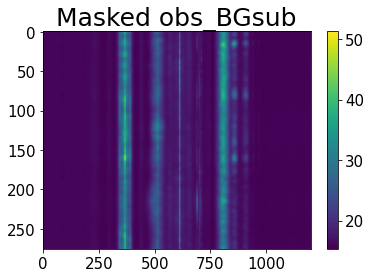

Size of arrays:
 - Frequency:  (1199,)
 - Time:  (276,)
 - Size of simulated Tb_factors:  (286, 1199)
 - Size of simulated sat_beam:  (73, 1199, 276)
 - Size of observations:  (1199, 276)


In [5]:
# initializing the simulation
sat = sim.SatelliteSimulation(
    survey_info=[pm.nd_s0, pm.frequency],
    path_catalog="Satellite_Catalogue/individual_satellite_constellation_catalog.csv",
    path_beam=f"{pm.block}_satellite_angular_positions_{pm.beam_model}_{pm.freq_range[0]}-{pm.freq_range[1]}.npz",
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=time_slice,
    verbose=True,
)

# getting observations
sat.use_observations(path_observations=pm.path_observations, verbose=True)

# applying mask
print("Masking...")
sat.use_mask(path_nearby, temp, pix, verbose=True)


In [6]:
# defining the cost function (only for testing, this won't be used in the optimization)
if CF=="C1":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=obs (case C1). '''
        sat.simulate(alphas)
        CF = np.sum( ((sat.obs_BGsub-sat.sim) / sat.obs)**2 )
        print(CF,end="\t")
        return CF
elif CF=="C2":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=1 (case C2). '''
        sat.simulate(alphas)
        CF = np.sum( (sat.obs_BGsub-sat.sim)**2 )
        print(CF,end="\t")
        return CF

# defining initial values (only for testing, this won't be used in the optimization)
alphas0 = np.zeros(len(sat.catalog))
_ = Cost_Function(alphas0)


6976740.588681895	

### 3. Running the optimization

#### A. Getting values

We now run the optimization with the functions and parameters defined above. This part of the code **needs approximately 15GB** of memory to run the `nnls` optimization, and it takes some minutes to run the code for the creation of matrixes A and b.

In [7]:
def optimization_setup(CF, verbose=True):  
    ''' Computes the necessary matrices A,b,Anorm for the nnls minimization. '''

    # in each satellite, loop through the specific signals
    A = np.empty((sat.obs_BGsub.size, len(sat.catalog)))
    if verbose:  print("Creating matrix A and b ...")
    for i_sat, start in enumerate(sat.index_sats):
        stop = start + sat.n_signals[i_sat]
        for i in range(start, stop):
            A[:, i] = (sat.sat_beam[i_sat] * sat.Tb_factors[i][:,None]).ravel()
    b = sat.obs_BGsub.ravel()

    # checking dimensions
    if verbose: 
        print(f" - Size of matrix A: {A.nbytes / 1024**3:.3f} GB")
        print(f" - Size of vector b: {b.nbytes / 1024**3:.3f} GB")

    # defining weights if necessary
    if verbose:  print("Applying weights...")
    if CF=="C1":  
        weights = 1.0 / sat.obs.ravel()
        A *= weights[:,None]
        b *= weights

    # normalizing for faster fitting
    if verbose:  print("Normalizing...")
    Anorm = np.linalg.norm(A, axis=0)
    Anorm[Anorm==0] = 1
    A /= Anorm
    
    return A,b,Anorm


In [8]:
# defining the optimization function
#def optimization_setup(CF):  
#    ''' Find optimal alphas with least squares weighted or not, 
#    by solving the linear problem |A*alpha - b|^2 with lsq_linear. '''
#
#    # creating matrix A
#    print("Creating matrix A (6 GB) and b ...")
#    A = np.empty((sat.obs_BGsub.size, len(sat.catalog)))
#    print("    30   60   90   120  150  180  210  240  270  300")
#    for j in range(len(sat.catalog)):
#        if (j%6==0):  print("|", end="")
#        alphas = np.zeros(len(sat.catalog))
#        alphas[j] = 1.0
#        sat.simulate(alphas)
#        A[:,j] = sat.sim.ravel()
#    b = sat.obs_BGsub.ravel()
#        
#    # defining weights if necessary
#    print("\nApplying weights...")
#    if CF=="C1":  
#        weights = 1.0 / sat.obs.ravel()
#        A *= weights[:,None]
#        b *= weights
#
#    # normalizing for faster fitting
#    print("Normalizing...")
#    Anorm = np.linalg.norm(A, axis=0)
#    Anorm[Anorm==0] = 1
#    A /= Anorm
#    
#    return A,b,Anorm


In [9]:
# setting up the optimization (creating matrixes A,b)
A,b,Anorm = optimization_setup(CF)


Creating matrix A and b ...
 - Size of matrix A: 0.705 GB
 - Size of vector b: 0.002 GB
Applying weights...
Normalizing...


In [10]:
# running the optimization
start = time.perf_counter()
print("Running optimization...")
x,rnorm = nnls(A, b, maxiter=1000)
print("Done.")
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Running optimization...
Done.
This took 19.85 seconds, or 0.33 minutes


#### B. Plotting best-fit

Getting catalog...
 - Number of signals in satellite catalog: 435 (initial), 286 (final).
Getting beam response...
 - Number of satellites present: 73
 - Size of sat_beam: 0.180 GB
Getting temperature factors for each signal...
 - Length of Tb_factors: 286
 - Size of Tb_factors: 0.003 GB
Starting index of satellites:  [  0   4   8  12  16  20  24  28  32  36  40  44  48  52  56  60  64  68
  72  76  80  84  88  92  96 100 104 108 112 114 116 118 120 122 123 124
 125 126 127 128 129 130 131 136 141 146 151 156 161 166 171 176 181 186
 191 196 201 206 211 216 221 226 231 236 241 246 251 256 261 266 271 276
 281]
Getting observational data...
 - Size of observational data: 0.002 GB
 - Shape of observational data: (1199, 276)
Masking...


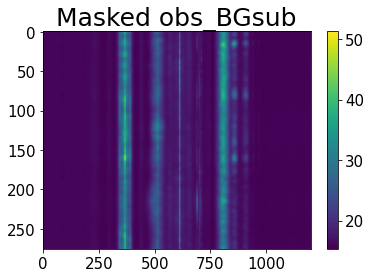

Size of arrays:
 - Frequency:  (1199,)
 - Time:  (276,)
 - Size of simulated Tb_factors:  (286, 1199)
 - Size of simulated sat_beam:  (73, 1199, 276)
 - Size of observations:  (1199, 276)


In [11]:
# saving best fit values
alphas_BF = x / Anorm

# simulating
# initializing the simulation
sat = sim.SatelliteSimulation(
    survey_info=[pm.nd_s0, pm.frequency],
    path_catalog="Satellite_Catalogue/individual_satellite_constellation_catalog.csv",
    path_beam=f"{pm.block}_satellite_angular_positions_{pm.beam_model}_{pm.freq_range[0]}-{pm.freq_range[1]}.npz",
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=time_slice,
    verbose=True,
)

# getting observations
sat.use_observations(path_observations=pm.path_observations, verbose=True)

# applying mask
print("Masking...")
sat.use_mask(path_nearby, temp, pix, verbose=True)

# using alphas
sat.simulate(alphas_BF)


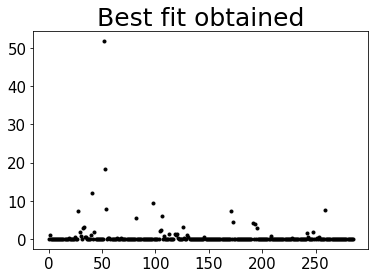

178986.30013455384	

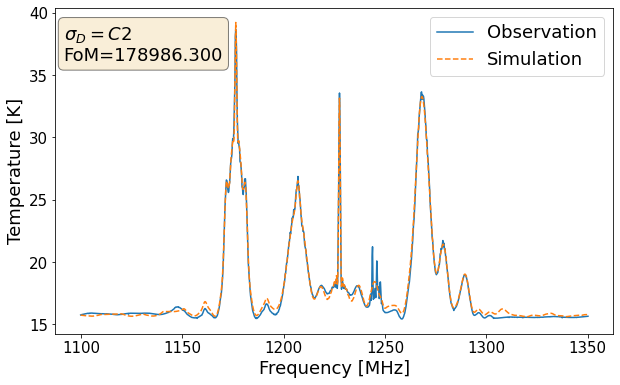

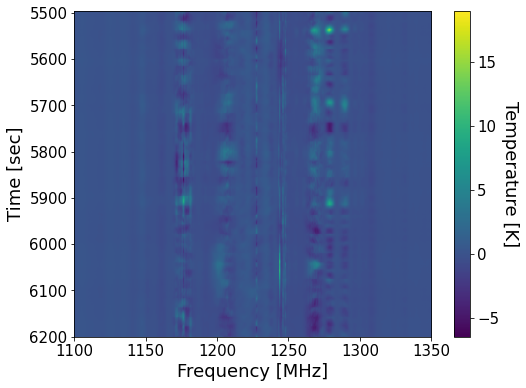

In [12]:
# plotting values
plt.plot(alphas_BF,"k.")
plt.title("Best fit obtained")
plt.show()

# plotting simulation
f = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(f, np.ma.mean(sat.obs_BGsub.T + sat.BG.T, axis=0), label='Observation')
ax.plot(f, np.ma.mean(sat.sim.T + sat.BG.T, axis=0), '--', label='Simulation')
textstr = f"$\\sigma_D={CF}$\nFoM={Cost_Function(alphas_BF):.3f}"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
ax.legend(loc='upper right')
plt.show()

# plotting simulation
t = sat.time[sat.itime[0]:sat.itime[1]]
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(sat.obs_BGsub.T - sat.sim.T, aspect='auto', extent=[f[0], f[-1], t[-1], t[0]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
plt.show()


In [13]:
# saving information in the file
data_info = {
    "initial" : alphas0,
    "CF" : CF,
    "mask_degree" : deg, 
    "mask_temperature" : temp, 
    "mask_pix" : pix, 
    "time_slice" : time_slice,
    "frequency_slice" : pm.freq_slice, 
    "best-fit" : alphas_BF,
}

print(f"Information saved in file '{fname}'.")
pickle.dump( data_info, open(fname,"wb") )


Information saved in file 'results/v4_results/interval5500-6200_C2.p'.
